# Exploratory Data Analysis (EDA)
## Sentiment-Driven Stock Prediction Dataset

This notebook performs comprehensive exploratory data analysis on the analyst ratings dataset, including:
- Descriptive Statistics
- Text Analysis & Topic Modeling
- Time Series Analysis
- Publisher Analysis


## 1. Setup and Data Loading


In [ ]:
# Standard library imports
import os
import sys
import warnings
from pathlib import Path
from datetime import datetime
import re
from collections import Counter

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# NLP and Text Analysis
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from wordcloud import WordCloud

# Time series analysis
from statsmodels.tsa.seasonal import seasonal_decompose

# Progress bars
from tqdm import tqdm

# Configure display options
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 100)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Download required NLTK data
# Handle both LookupError (missing) and BadZipFile (corrupted) errors
import zipfile

def ensure_nltk_data(resource_name, download_name=None):
    """Ensure NLTK resource is available, re-download if corrupted."""
    if download_name is None:
        download_name = resource_name.split('/')[-1]
    
    try:
        nltk.data.find(resource_name)
        return True
    except (LookupError, zipfile.BadZipFile, OSError) as e:
        print(f"  Downloading {download_name}...")
        try:
            nltk.download(download_name, quiet=True)
            # Verify it was downloaded correctly
            nltk.data.find(resource_name)
            return True
        except Exception as download_error:
            print(f"  ⚠ Warning: Could not download {download_name}: {download_error}")
            return False

print("Checking NLTK data...")
# Download punkt (legacy) and punkt_tab (newer version)
ensure_nltk_data('tokenizers/punkt', 'punkt')
ensure_nltk_data('tokenizers/punkt_tab', 'punkt_tab')
ensure_nltk_data('corpora/stopwords', 'stopwords')
ensure_nltk_data('corpora/wordnet', 'wordnet')

print("✓ Libraries imported successfully")


Checking NLTK data...
  ⚠ Warning: Could not download wordnet: File is not a zip file
✓ Libraries imported successfully


In [2]:
# Set project root and data path
# Handle both cases: running from notebook directory or project root
current_dir = Path.cwd()
if current_dir.name == 'notebooks':
    project_root = current_dir.parent
else:
    project_root = current_dir

data_path = project_root / "data" / "raw_analyst_ratings.csv"

print(f"Current working directory: {current_dir}")
print(f"Project root: {project_root}")
print(f"Data path: {data_path}")
print(f"Data file exists: {data_path.exists()}")

if not data_path.exists():
    print(f"\n⚠ WARNING: Data file not found at {data_path}")
    print("Please ensure the data file is in the correct location.")


Current working directory: /home/haben/Project/KAIM-Training-Portfolio/sentiment-driven-stock-prediction/notebooks
Project root: /home/haben/Project/KAIM-Training-Portfolio/sentiment-driven-stock-prediction
Data path: /home/haben/Project/KAIM-Training-Portfolio/sentiment-driven-stock-prediction/data/raw_analyst_ratings.csv
Data file exists: True


In [3]:
# Load data with chunking for large file
print("Loading dataset...")
chunk_size = 100000
chunks = []

# Get total number of rows for progress bar (estimate)
try:
    # Try to get file size for better progress estimation
    file_size = data_path.stat().st_size
    estimated_rows = int(file_size / 500)  # Rough estimate: ~500 bytes per row
    total_chunks = max(1, estimated_rows // chunk_size)
except:
    total_chunks = None

# Read in chunks with progress bar
chunk_reader = pd.read_csv(data_path, chunksize=chunk_size)
for chunk in tqdm(chunk_reader, desc="Loading chunks", total=total_chunks):
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
print(f"\n✓ Dataset loaded successfully")
print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Loading dataset...


Loading chunks: 15it [00:04,  3.69it/s]                      



✓ Dataset loaded successfully
Shape: (1407328, 6)
Memory usage: 634.55 MB


In [4]:
# Initial data inspection
print("Dataset Overview:")
print("=" * 50)
df.info()
print("\n" + "=" * 50)
print("\nFirst few rows:")
df.head(10)


Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB


First few rows:


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/stocks-that-hit-52-week-highs-on-friday,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/stocks-that-hit-52-week-highs-on-wednesday,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/71-biggest-movers-from-friday,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/46-stocks-moving-in-fridays-mid-day-session,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,"B of A Securities Maintains Neutral on Agilent Technologies, Raises Price Target to $88",https://www.benzinga.com/news/20/05/16095304/b-of-a-securities-maintains-neutral-on-agilent-tech...,Vick Meyer,2020-05-22 11:38:59-04:00,A
5,5,"CFRA Maintains Hold on Agilent Technologies, Lowers Price Target to $85",https://www.benzinga.com/news/20/05/16095163/cfra-maintains-hold-on-agilent-technologies-lowers-...,vishwanath@benzinga.com,2020-05-22 11:23:25-04:00,A
6,6,"UBS Maintains Neutral on Agilent Technologies, Raises Price Target to $87",https://www.benzinga.com/news/20/05/16094027/ubs-maintains-neutral-on-agilent-technologies-raise...,vishwanath@benzinga.com,2020-05-22 09:36:20-04:00,A
7,7,Agilent Technologies shares are trading higher after the company reported better-than-expected Q...,https://www.benzinga.com/wiim/20/05/16093805/agilent-technologies-shares-are-trading-higher-afte...,Benzinga Newsdesk,2020-05-22 09:07:04-04:00,A
8,8,"Wells Fargo Maintains Overweight on Agilent Technologies, Raises Price Target to $95",https://www.benzinga.com/news/20/05/16093505/wells-fargo-maintains-overweight-on-agilent-technol...,vishwanath@benzinga.com,2020-05-22 08:37:59-04:00,A
9,9,10 Biggest Price Target Changes For Friday,https://www.benzinga.com/analyst-ratings/price-target/20/05/16093262/10-biggest-price-target-cha...,Lisa Levin,2020-05-22 08:06:17-04:00,A


In [5]:
# Check for missing values
print("Missing Values:")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing Percentage': missing_pct.values
})
print(missing_df[missing_df['Missing Count'] > 0])
print("\n✓ No missing values" if missing.sum() == 0 else "\n⚠ Missing values detected")


Missing Values:
Empty DataFrame
Columns: [Column, Missing Count, Missing Percentage]
Index: []

✓ No missing values


## 2. Data Preprocessing


In [6]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Extract temporal features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.day_name()
df['hour'] = df['date'].dt.hour
df['date_only'] = df['date'].dt.date

# Calculate headline length
df['headline_length'] = df['headline'].str.len()
df['headline_word_count'] = df['headline'].str.split().str.len()

print("✓ Data preprocessing completed")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Total unique dates: {df['date_only'].nunique()}")


✓ Data preprocessing completed
Date range: 2011-04-27 21:01:48-04:00 to 2020-06-11 17:12:35-04:00
Total unique dates: 2528


## 3. Descriptive Statistics


In [7]:
print("DESCRIPTIVE STATISTICS")
print("=" * 70)

# Headline length statistics
print("\n1. Headline Length Statistics:")
print("-" * 70)
headline_stats = df['headline_length'].describe()
print(headline_stats)

print("\n2. Headline Word Count Statistics:")
print("-" * 70)
word_count_stats = df['headline_word_count'].describe()
print(word_count_stats)


DESCRIPTIVE STATISTICS

1. Headline Length Statistics:
----------------------------------------------------------------------
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

2. Headline Word Count Statistics:
----------------------------------------------------------------------
count    1.407328e+06
mean     1.141671e+01
std      6.352997e+00
min      1.000000e+00
25%      7.000000e+00
50%      1.000000e+01
75%      1.300000e+01
max      7.700000e+01
Name: headline_word_count, dtype: float64


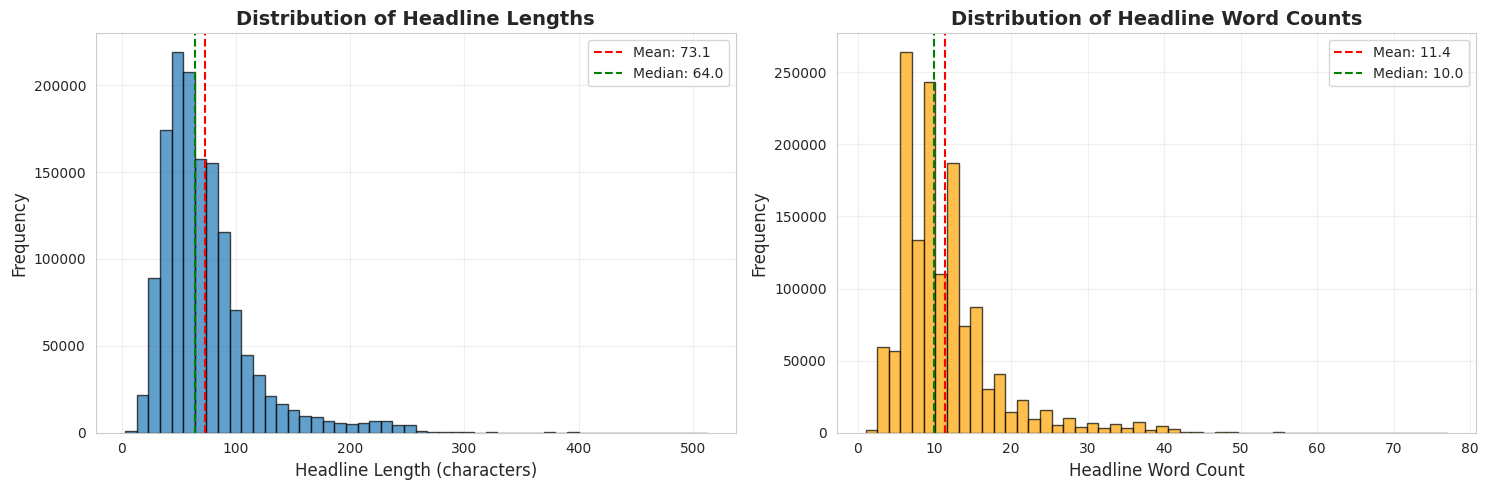

In [8]:
# Create figures directory if it doesn't exist
os.makedirs(project_root / 'notebooks' / 'figures', exist_ok=True)

# Visualize headline length distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Headline length distribution
axes[0].hist(df['headline_length'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['headline_length'].mean(), color='red', linestyle='--', 
                label=f'Mean: {df["headline_length"].mean():.1f}')
axes[0].axvline(df['headline_length'].median(), color='green', linestyle='--', 
                label=f'Median: {df["headline_length"].median():.1f}')
axes[0].set_xlabel('Headline Length (characters)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Headline Lengths', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Word count distribution
axes[1].hist(df['headline_word_count'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(df['headline_word_count'].mean(), color='red', linestyle='--', 
                label=f'Mean: {df["headline_word_count"].mean():.1f}')
axes[1].axvline(df['headline_word_count'].median(), color='green', linestyle='--', 
                label=f'Median: {df["headline_word_count"].median():.1f}')
axes[1].set_xlabel('Headline Word Count', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Headline Word Counts', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / 'notebooks' / 'figures' / 'headline_length_distributions.png', 
            dpi=300, bbox_inches='tight')
plt.show()


In [9]:
# Articles per publisher
print("3. Articles per Publisher:")
print("-" * 70)
publisher_counts = df['publisher'].value_counts()
print(f"Total unique publishers: {df['publisher'].nunique()}")
print(f"\nTop 20 Most Active Publishers:")
print(publisher_counts.head(20))

# Statistics on publisher activity
print(f"\nPublisher Activity Statistics:")
print(f"  - Mean articles per publisher: {publisher_counts.mean():.2f}")
print(f"  - Median articles per publisher: {publisher_counts.median():.2f}")
print(f"  - Max articles by single publisher: {publisher_counts.max()}")
print(f"  - Publishers with >1000 articles: {(publisher_counts > 1000).sum()}")
print(f"  - Publishers with >100 articles: {(publisher_counts > 100).sum()}")


3. Articles per Publisher:
----------------------------------------------------------------------
Total unique publishers: 1034

Top 20 Most Active Publishers:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590
Name: count, dtype: int64

Publisher Activity Statistics:
  - Mean articles per publisher: 1361.05
  - Median articles per publisher: 11.00
  - Max articles by single publisher: 228373
  - Publishers with >1000 articles: 85
  - Publishers with >100 articles: 253


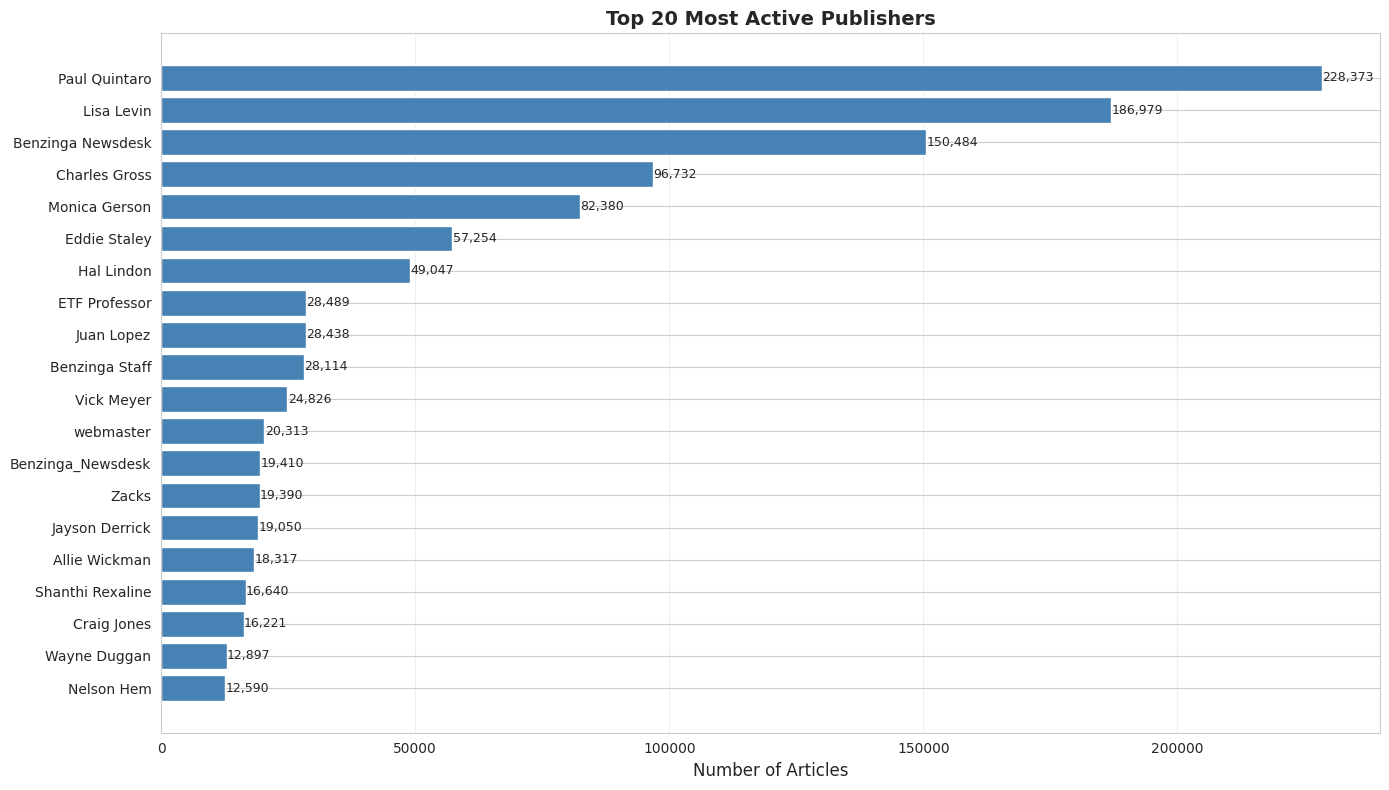

In [10]:
# Visualize top publishers
top_publishers = publisher_counts.head(20)

plt.figure(figsize=(14, 8))
bars = plt.barh(range(len(top_publishers)), top_publishers.values, color='steelblue')
plt.yticks(range(len(top_publishers)), top_publishers.index)
plt.xlabel('Number of Articles', fontsize=12)
plt.title('Top 20 Most Active Publishers', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels on bars
for i, (idx, val) in enumerate(zip(top_publishers.index, top_publishers.values)):
    plt.text(val + 100, i, f'{val:,}', va='center', fontsize=9)

plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(project_root / 'notebooks' / 'figures' / 'top_publishers.png', 
            dpi=300, bbox_inches='tight')
plt.show()


In [21]:
# Publication date trends
print("4. Publication Date Analysis:")
print("-" * 70)

# Ensure date column is datetime and date_only column exists
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

if 'date_only' not in df.columns:
    df['date_only'] = df['date'].dt.date

# Articles per day
articles_per_day = df.groupby('date_only').size().sort_index()
print(f"Date range: {articles_per_day.index.min()} to {articles_per_day.index.max()}")
print(f"Total days with articles: {len(articles_per_day)}")
print(f"\nDaily Article Statistics:")
print(articles_per_day.describe())

# Articles by day of week
print(f"\n5. Articles by Day of Week:")
print("-" * 70)

# Ensure date column is datetime and temporal features exist
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

if 'day_of_week' not in df.columns:
    df['day_of_week'] = df['date'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
articles_by_dow = df['day_of_week'].value_counts().reindex(day_order)
print(articles_by_dow)

# Articles by month
print(f"\n6. Articles by Month:")
print("-" * 70)

# Ensure date column is datetime and month column exists
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

if 'month' not in df.columns:
    df['month'] = df['date'].dt.month

month_names = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
articles_by_month = df['month'].value_counts().sort_index()

# Filter out NaN values and ensure integer indices
articles_by_month = articles_by_month.dropna()
articles_by_month.index = articles_by_month.index.astype(int)

# Map month numbers to month names
month_name_mapping = {i+1: name for i, name in enumerate(month_names)}
articles_by_month.index = [month_name_mapping.get(i, f'Month {i}') for i in articles_by_month.index]
print(articles_by_month)


4. Publication Date Analysis:
----------------------------------------------------------------------
Date range: 2011-04-27 to 2020-06-11
Total days with articles: 2528

Daily Article Statistics:
count    2528.000000
mean       22.146756
std        68.144109
min         1.000000
25%         3.000000
50%         9.000000
75%        17.000000
max       973.000000
dtype: float64

5. Articles by Day of Week:
----------------------------------------------------------------------
day_of_week
Monday       10322
Tuesday      11002
Wednesday    11891
Thursday     12688
Friday        9381
Saturday       267
Sunday         436
Name: count, dtype: int64

6. Articles by Month:
----------------------------------------------------------------------
January       3068
February      4091
March         6391
April         6468
May          11363
June          7968
July          2131
August        2858
September     2417
October       3079
November      3210
December      2943
Name: count, dtype: int64


## 4. Text Analysis & Topic Modeling


In [22]:
# Text preprocessing function
def preprocess_text(text):
    """Clean and preprocess text for analysis."""
    if pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    
    # Remove special characters but keep spaces
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]
    
    return ' '.join(tokens)

print("Preprocessing text data (this may take a while)...")

# Ensure punkt_tab is downloaded (required for newer NLTK versions)
try:
    nltk.data.find('tokenizers/punkt_tab')
except (LookupError, zipfile.BadZipFile):
    print("  Downloading punkt_tab (required for tokenization)...")
    try:
        nltk.download('punkt_tab', quiet=True)
    except Exception as e:
        print(f"  ⚠ Warning: Could not download punkt_tab: {e}")

# Enable tqdm for pandas
try:
    tqdm.pandas(desc="Processing headlines")
    df['processed_headline'] = df['headline'].progress_apply(preprocess_text)
except AttributeError:
    # Fallback if tqdm.pandas is not available
    print("Using standard apply (tqdm.pandas not available)...")
    df['processed_headline'] = df['headline'].apply(preprocess_text)
except LookupError as e:
    # If punkt_tab still not found, try downloading again and use fallback
    if 'punkt_tab' in str(e):
        print("  Attempting to download punkt_tab again...")
        nltk.download('punkt_tab', quiet=False)
        print("  Retrying preprocessing...")
        df['processed_headline'] = df['headline'].apply(preprocess_text)
    else:
        raise
print("\n✓ Text preprocessing completed")


Preprocessing text data (this may take a while)...


Processing headlines: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1407328/1407328 [02:08<00:00, 10913.66it/s]


✓ Text preprocessing completed


In [23]:
# Extract common keywords and phrases
print("Extracting keywords and phrases...")

# Get all processed text
all_text = ' '.join(df['processed_headline'].dropna())

# Tokenize and count
tokens = word_tokenize(all_text)
word_freq = Counter(tokens)

print(f"\nTotal unique words: {len(word_freq)}")
print(f"\nTop 50 Most Common Keywords:")
print("-" * 70)
for word, count in word_freq.most_common(50):
    print(f"{word:20s}: {count:,}")


Extracting keywords and phrases...

Total unique words: 93010

Top 50 Most Common Keywords:
----------------------------------------------------------------------
stocks              : 161,776
est                 : 140,650
eps                 : 128,917
market              : 120,560
shares              : 114,315
reports             : 108,711
update              : 91,722
earnings            : 87,399
sales               : 79,648
top                 : 79,632
benzinga            : 74,510
week                : 69,572
announces           : 66,591
price               : 64,406
buy                 : 64,374
mid                 : 62,263
downgrades          : 61,959
trading             : 61,183
raises              : 57,801
upgrades            : 56,811
target              : 54,717
maintains           : 52,961
higher              : 48,286
new                 : 48,228
day                 : 46,146
session             : 45,349
inc                 : 45,190
says                : 43,134
moving             

In [ ]:
# Create word cloud
print("Generating word cloud...")

# Filter out very common but less meaningful words
filtered_freq = {word: count for word, count in word_freq.items() 
                 if word not in ['stock', 'stocks', 'company', 'companies', 'shares']}

wordcloud = WordCloud(width=1200, height=600, background_color='white',
                      max_words=200, colormap='viridis').generate_from_frequencies(filtered_freq)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Keywords in Headlines', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(project_root / 'notebooks' / 'figures' / 'wordcloud.png', 
            dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Extract key phrases (bigrams and trigrams)
print("Extracting key phrases...")

# Sample data for phrase extraction (due to computational constraints)
sample_size = min(50000, len(df))
sample_df = df.sample(n=sample_size, random_state=42)

# Extract bigrams
from nltk import bigrams, trigrams

all_bigrams = []
all_trigrams = []

for text in tqdm(sample_df['processed_headline'], desc="Extracting phrases"):
    tokens = word_tokenize(str(text))
    all_bigrams.extend(list(bigrams(tokens)))
    all_trigrams.extend(list(trigrams(tokens)))

bigram_freq = Counter([' '.join(bg) for bg in all_bigrams])
trigram_freq = Counter([' '.join(tg) for tg in all_trigrams])

print(f"\nTop 20 Bigrams:")
print("-" * 70)
for phrase, count in bigram_freq.most_common(20):
    print(f"{phrase:40s}: {count:,}")

print(f"\nTop 20 Trigrams:")
print("-" * 70)
for phrase, count in trigram_freq.most_common(20):
    print(f"{phrase:50s}: {count:,}")


In [ ]:
# Topic Modeling using LDA
print("Performing Topic Modeling with LDA...")
print("-" * 70)

# Use sample for topic modeling
sample_texts = sample_df['processed_headline'].dropna().tolist()

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=1000, min_df=5, max_df=0.95)
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_texts)

# Apply LDA
n_topics = 10
lda_model = LatentDirichletAllocation(n_components=n_topics, random_state=42, 
                                      max_iter=10, learning_method='online')
lda_model.fit(tfidf_matrix)

# Display topics
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"\nIdentified {n_topics} Topics:")
print("=" * 70)
for topic_idx, topic in enumerate(lda_model.components_):
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"\nTopic {topic_idx + 1}:")
    print(f"  Top words: {', '.join(top_words)}")


In [ ]:
# Search for specific key phrases
print("Searching for Specific Key Phrases:")
print("-" * 70)

key_phrases = {
    'FDA approval': r'fda\s+approval',
    'Price target': r'price\s+target',
    'Earnings': r'earnings|eps',
    'Upgrade': r'upgrade',
    'Downgrade': r'downgrade',
    'Maintains': r'maintains',
    'Raises': r'raises',
    'Lowers': r'lowers',
    '52-week high': r'52\s*[-\s]*week\s+high',
    '52-week low': r'52\s*[-\s]*week\s+low'
}

phrase_counts = {}
for phrase, pattern in key_phrases.items():
    count = df['headline'].str.contains(pattern, case=False, na=False).sum()
    phrase_counts[phrase] = count
    print(f"{phrase:20s}: {count:,} articles ({count/len(df)*100:.2f}%)")

# Visualize key phrases
plt.figure(figsize=(12, 6))
phrases = list(phrase_counts.keys())
counts = list(phrase_counts.values())
plt.barh(phrases, counts, color='coral')
plt.xlabel('Number of Articles', fontsize=12)
plt.title('Frequency of Key Phrases in Headlines', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
for i, v in enumerate(counts):
    plt.text(v + 100, i, f'{v:,}', va='center', fontsize=9)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(project_root / 'notebooks' / 'figures' / 'key_phrases.png', 
            dpi=300, bbox_inches='tight')
plt.show()


## 5. Time Series Analysis


In [ ]:
# Publication frequency over time
print("TIME SERIES ANALYSIS")
print("=" * 70)

# Ensure date column is datetime and date_only column exists
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

if 'date_only' not in df.columns:
    df['date_only'] = df['date'].dt.date

# Convert date_only to datetime for time series analysis
# Handle both date objects and datetime objects
if df['date_only'].dtype == 'object':
    df['date_only'] = pd.to_datetime(df['date_only'])
elif not pd.api.types.is_datetime64_any_dtype(df['date_only']):
    df['date_only'] = pd.to_datetime(df['date_only'])

# Create time series data
daily_counts = df.groupby('date_only').size().reset_index()
daily_counts.columns = ['date', 'article_count']
daily_counts = daily_counts.sort_values('date')
daily_counts.set_index('date', inplace=True)

print(f"\n1. Daily Publication Frequency:")
print(f"   Date range: {daily_counts.index.min()} to {daily_counts.index.max()}")
print(f"   Total days: {len(daily_counts)}")
print(f"   Mean articles per day: {daily_counts['article_count'].mean():.2f}")
print(f"   Max articles in a single day: {daily_counts['article_count'].max()}")
print(f"   Date with max articles: {daily_counts['article_count'].idxmax()}")


In [ ]:
# Plot time series
fig = make_subplots(rows=2, cols=1, 
                    subplot_titles=('Daily Article Count Over Time', 
                                   'Rolling 7-Day Average'),
                    vertical_spacing=0.15)

# Daily counts
fig.add_trace(
    go.Scatter(x=daily_counts.index, y=daily_counts['article_count'],
              mode='lines', name='Daily Count', line=dict(color='steelblue', width=1)),
    row=1, col=1
)

# Rolling average
rolling_avg = daily_counts['article_count'].rolling(window=7).mean()
fig.add_trace(
    go.Scatter(x=rolling_avg.index, y=rolling_avg.values,
              mode='lines', name='7-Day Average', line=dict(color='red', width=2)),
    row=2, col=1
)

fig.update_xaxes(title_text="Date", row=2, col=1)
fig.update_yaxes(title_text="Article Count", row=1, col=1)
fig.update_yaxes(title_text="Article Count", row=2, col=1)
fig.update_layout(height=800, showlegend=True, 
                  title_text="Publication Frequency Over Time")

fig.write_html(str(project_root / 'notebooks' / 'figures' / 'time_series.html'))
fig.show()


In [ ]:
# Identify spikes in publication
print("\n2. Publication Spikes (Top 20 Days with Most Articles):")
print("-" * 70)
top_days = daily_counts.nlargest(20, 'article_count')
for date, count in top_days.iterrows():
    print(f"{date.strftime('%Y-%m-%d')}: {count['article_count']:,} articles")


In [ ]:
# Analyze publishing times
print("\n3. Publishing Time Analysis:")
print("-" * 70)

# Ensure date column is datetime and hour column exists
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

if 'hour' not in df.columns:
    df['hour'] = df['date'].dt.hour

# Articles by hour of day
hourly_counts = df['hour'].value_counts().sort_index()
print(f"\nArticles by Hour of Day:")
print(f"  Peak hour: {hourly_counts.idxmax()} (00:00-23:59 format)")
print(f"  Peak hour articles: {hourly_counts.max():,}")
print(f"  Quietest hour: {hourly_counts.idxmin()}")
print(f"  Quietest hour articles: {hourly_counts.min():,}")

# Visualize hourly distribution
plt.figure(figsize=(14, 6))
plt.bar(hourly_counts.index, hourly_counts.values, color='teal', alpha=0.7)
plt.xlabel('Hour of Day (24-hour format)', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.title('Article Publication Times Throughout the Day', fontsize=14, fontweight='bold')
plt.xticks(range(24))
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(project_root / 'notebooks' / 'figures' / 'hourly_distribution.png', 
            dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Monthly trends
print("\n4. Monthly Publication Trends:")
print("-" * 70)

# Create year-month column
df['year_month'] = df['date'].dt.to_period('M')
monthly_counts = df.groupby('year_month').size()

print(f"Total months: {len(monthly_counts)}")
print(f"Mean articles per month: {monthly_counts.mean():.2f}")
print(f"\nTop 10 Months by Article Count:")
for period, count in monthly_counts.nlargest(10).items():
    print(f"  {period}: {count:,} articles")

# Visualize monthly trends
plt.figure(figsize=(16, 6))
monthly_counts.plot(kind='line', marker='o', color='purple', linewidth=2, markersize=4)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.title('Monthly Publication Trends', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(project_root / 'notebooks' / 'figures' / 'monthly_trends.png', 
            dpi=300, bbox_inches='tight')
plt.show()


## 6. Publisher Analysis


In [ ]:
print("PUBLISHER ANALYSIS")
print("=" * 70)

# Identify email addresses vs. names
email_pattern = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
df['is_email'] = df['publisher'].str.match(email_pattern, na=False)

print(f"\n1. Publisher Type Analysis:")
print("-" * 70)
print(f"  Total publishers: {df['publisher'].nunique()}")
print(f"  Email addresses as publishers: {df['is_email'].sum():,} ({df['is_email'].sum()/len(df)*100:.2f}%)")
print(f"  Named publishers: {(~df['is_email']).sum():,} ({(~df['is_email']).sum()/len(df)*100:.2f}%)")


In [ ]:
# Extract email domains
print("\n2. Email Domain Analysis:")
print("-" * 70)

email_publishers = df[df['is_email']]['publisher']
domains = email_publishers.str.extract(r'@([\w.]+)')[0]
domain_counts = domains.value_counts()

print(f"  Unique email domains: {domain_counts.nunique()}")
print(f"\n  Top 20 Email Domains:")
for domain, count in domain_counts.head(20).items():
    print(f"    {domain:30s}: {count:,} articles")

# Visualize top domains
plt.figure(figsize=(12, 8))
top_domains = domain_counts.head(15)
plt.barh(range(len(top_domains)), top_domains.values, color='darkgreen')
plt.yticks(range(len(top_domains)), top_domains.index)
plt.xlabel('Number of Articles', fontsize=12)
plt.title('Top 15 Email Domains Used as Publishers', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
for i, v in enumerate(top_domains.values):
    plt.text(v + 50, i, f'{v:,}', va='center', fontsize=9)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(project_root / 'notebooks' / 'figures' / 'email_domains.png', 
            dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Analyze publisher characteristics
print("\n3. Publisher Characteristics:")
print("-" * 70)

# Average headline length by publisher (top 20)
top_20_publishers = publisher_counts.head(20).index
publisher_stats = df[df['publisher'].isin(top_20_publishers)].groupby('publisher').agg({
    'headline_length': ['mean', 'std'],
    'headline_word_count': ['mean', 'std'],
    'date': 'count'
}).round(2)

publisher_stats.columns = ['Avg_Length', 'Std_Length', 'Avg_Words', 'Std_Words', 'Article_Count']
publisher_stats = publisher_stats.sort_values('Article_Count', ascending=False)

print("\n  Statistics for Top 20 Publishers:")
print(publisher_stats)


In [ ]:
# Publisher activity over time
print("\n4. Publisher Activity Trends:")
print("-" * 70)

# Top 10 publishers activity by year
top_10_publishers = publisher_counts.head(10).index
publisher_yearly = df[df['publisher'].isin(top_10_publishers)].groupby(['year', 'publisher']).size().unstack(fill_value=0)

print("\n  Yearly Activity for Top 10 Publishers:")
print(publisher_yearly)

# Visualize
plt.figure(figsize=(16, 8))
for publisher in top_10_publishers[:5]:  # Show top 5 for clarity
    if publisher in publisher_yearly.columns:
        plt.plot(publisher_yearly.index, publisher_yearly[publisher], 
                marker='o', label=publisher, linewidth=2)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.title('Publisher Activity Trends Over Time (Top 5 Publishers)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(project_root / 'notebooks' / 'figures' / 'publisher_trends.png', 
            dpi=300, bbox_inches='tight')
plt.show()


## 7. Summary and Key Findings


In [ ]:
print("EDA SUMMARY AND KEY FINDINGS")
print("=" * 70)

# Build summary with error handling for variables that might not exist
summary = {
    'Dataset Size': f"{len(df):,} articles",
    'Date Range': f"{df['date'].min()} to {df['date'].max()}",
    'Unique Publishers': f"{df['publisher'].nunique():,}",
    'Unique Stocks': f"{df['stock'].nunique():,}",
    'Avg Headline Length': f"{df['headline_length'].mean():.1f} characters",
    'Avg Headline Words': f"{df['headline_word_count'].mean():.1f} words",
}

# Add optional statistics if variables exist
try:
    if 'publisher_counts' in locals() and len(publisher_counts) > 0:
        summary['Most Active Publisher'] = f"{publisher_counts.index[0]} ({publisher_counts.iloc[0]:,} articles)"
except:
    summary['Most Active Publisher'] = "N/A"

try:
    if 'hourly_counts' in locals() and len(hourly_counts) > 0:
        summary['Peak Publication Hour'] = f"{hourly_counts.idxmax()}:00"
except:
    summary['Peak Publication Hour'] = "N/A"

try:
    if 'is_email' in df.columns:
        summary['Email Publishers'] = f"{df['is_email'].sum():,} ({df['is_email'].sum()/len(df)*100:.1f}%)"
except:
    summary['Email Publishers'] = "N/A"

try:
    if 'domain_counts' in locals() and len(domain_counts) > 0:
        summary['Unique Email Domains'] = f"{domain_counts.nunique()}"
except:
    summary['Unique Email Domains'] = "N/A"

print("\nKey Statistics:")
for key, value in summary.items():
    print(f"  {key:25s}: {value}")

print("\n" + "=" * 70)
print("✓ Exploratory Data Analysis Completed Successfully")
print("=" * 70)
